In [ ]:
!pip install gensim bertopic top2vec umap-learn hdbscan sentence-transformers pyLDAvis scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 114.4 MB/s eta 0:00:00


In [ ]:
import gzip, json, re, time, tracemalloc, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample

from gensim import corpora
from gensim.models import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel

from bertopic import BERTopic
from top2vec import Top2Vec

In [ ]:
import os
size_mb = os.path.getsize("/content/All_Beauty.gz") / 1024 / 1024
print(f"File size: {size_mb:.2f} MB")

File size: 44.49 MB


In [ ]:
path = "/content/All_Beauty.gz"
reviews = []

with gzip.open(path, 'rt', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if 'reviewText' in data and isinstance(data['reviewText'], str):
            reviews.append(data['reviewText'])

df = pd.DataFrame(reviews, columns=['review'])
print(f"Total reviews loaded: {df.shape[0]}")


Total reviews loaded: 370946


,review
0,great
1,My husband wanted to reading about the Negro ...
2,"This book was very informative, covering all a..."
3,I am already a baseball fan and knew a bit abo...
4,This was a good story of the Black leagues. I ...


In [ ]:
df.head(15)

,review,clean_review
0,great,great
1,My husband wanted to reading about the Negro ...,husband wanted reading negro baseball great ad...
2,"This book was very informative, covering all a...",book informative covering aspect game
3,I am already a baseball fan and knew a bit abo...,already baseball fan knew bit negro league lea...
4,This was a good story of the Black leagues. I ...,good story black league bought book teach high...
5,Today I gave a book about the Negro Leagues of...,today gave book negro league baseball travelin...
6,The story of race relations in American histor...,story race relation american history one lost ...
7,I didn't like this product it smudged all unde...,didnt like product smudged eye throughly day
8,I simply love the product. I appreciate print ...,simply love product appreciate print feed back...
9,it burns your eyes when u put it on and very ...,burn eye put light keep going back forth lot g...


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

# Drop empty reviews after cleaning
df = df[df['clean_review'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"After cleaning: {df.shape[0]} reviews")
df.head()

After cleaning: 369590 reviews


,review,clean_review
0,great,great
1,My husband wanted to reading about the Negro ...,husband wanted reading negro baseball great ad...
2,"This book was very informative, covering all a...",book informative covering aspect game
3,I am already a baseball fan and knew a bit abo...,already baseball fan knew bit negro league lea...
4,This was a good story of the Black leagues. I ...,good story black league bought book teach high...


# CELL 5 — Subset Sizes & Helper Functions

###### What it is: A list of four numbers representing how many reviews we will feed into each algorithm during testing.
###### Why we did this: The assignment specifically asks us to measure scalability — meaning how does each algorithm behave as data grows? We don't just run each algorithm once on the full dataset. Instead, we run it four times, each time with more data:

#### topic_diversity
######  What it measures: How different the topics are from each other.
#### How it works:
##### How: Takes top 10 words from each topic → counts how many are unique across all topics → divides by total words. Score of 1.0 = perfect, every topic has completely different words. Score of 0.5 = half the words are shared between topics.

##### Why we need it: An algorithm might find 10 topics but if they all say the same words, the result is useless. This metric catches that problem.

###### Function 2 — Topic Uniqueness
What it measures: Across the entire model output, how many words appear only once vs being repeated?
How it works:

Flattens all topics into one big list of words
Compares unique words to total words
Returns: unique words / total words

Difference from Diversity: Diversity looks at the top K words per topic. Uniqueness looks at all words across topics with no cutoff. It's a stricter global measure.
Why we need it: An algorithm might score well on diversity by accident (e.g., if topics are small). Uniqueness gives us a second angle to confirm that topic overlap is genuinely low across the whole model.

Function 3 — Topic Coherence (C_v)
What it measures: Do the words within each topic actually appear together in real reviews? This is the most important quality metric.
How it works:

Uses Gensim's CoherenceModel with the c_v method
c_v works by checking how often pairs of top words co-occur in a sliding window across the actual review texts
Higher co-occurrence = words belong together = topic makes sense

Why the try/except: Some algorithms like BERTopic or Top2Vec may produce topics with words not in the Gensim dictionary (they use neural embeddings, not bag-of-words). The try/except prevents the whole loop from crashing if coherence can't be computed for one subset — it just returns None and we move on.

In [ ]:
# A list of four different dataset sizes we will test each algorithm on.
subset_sizes = [10000, 30000, 50000, 100000]

# ── Quality metric helpers ──────────────────────────────────────────────────

def topic_diversity(topics, top_k=10):
    unique_words, total_words = set(), 0
    for topic in topics:
        words = topic[:top_k]
        unique_words.update(words)
        total_words += len(words)
    return len(unique_words) / total_words if total_words > 0 else 0

def topic_uniqueness(topics):
    all_words = [w for topic in topics for w in topic]
    return len(set(all_words)) / len(all_words) if all_words else 0

def get_coherence(topics_words, texts, dictionary):
    try:
        cm = CoherenceModel(
            topics=topics_words,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        return cm.get_coherence()
    except Exception as e:
        print(f"  Coherence error: {e}")
        return None

# LDA

What LDA does: Latent Dirichlet Allocation assumes every document is a mixture of topics, and every topic is a mixture of words. It finds the topic-word distributions that best explain the whole corpus.

In [ ]:
lda_results = []

for size in subset_sizes:
    print(f"\n── LDA | subset = {size} ──")
    subset = df['clean_review'].sample(n=size, random_state=42).tolist()
    texts  = [doc.split() for doc in subset]

    dictionary = corpora.Dictionary(texts)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(t) for t in texts]

    # ── Training ──
    tracemalloc.start()
    t0 = time.time()

    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=10,
        passes=5,
        chunksize=2000,
        workers=2,
        random_state=42
    )

    train_time = time.time() - t0
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mem_mb = peak_mem / 1024 / 1024

    # ── Inference time (on 500 held-out docs) ──
    held_out = [dictionary.doc2bow(t) for t in texts[:500]]
    t_inf = time.time()
    _ = [lda_model.get_document_topics(doc) for doc in held_out]
    inf_time = (time.time() - t_inf) / 500

    # ── Topics ──
    topics_words = [[w for w, _ in lda_model.show_topic(i, topn=10)] for i in range(10)]

    # ── Quality ──
    coherence  = get_coherence(topics_words, texts, dictionary)
    diversity  = topic_diversity(topics_words)
    uniqueness = topic_uniqueness(topics_words)
    perplexity = lda_model.log_perplexity(corpus)

    print(f"  Train time   : {train_time:.2f}s")
    print(f"  Peak memory  : {peak_mem_mb:.2f} MB")
    print(f"  Inf time/doc : {inf_time*1000:.4f} ms")
    print(f"  Coherence    : {coherence:.4f}")
    print(f"  Diversity    : {diversity:.4f}")
    print(f"  Uniqueness   : {uniqueness:.4f}")
    print(f"  Perplexity   : {perplexity:.4f}")

    lda_results.append({
        'algorithm': 'LDA',
        'subset_size': size,
        'train_time': train_time,
        'peak_mem_mb': peak_mem_mb,
        'inf_time_ms': inf_time * 1000,
        'coherence': coherence,
        'diversity': diversity,
        'uniqueness': uniqueness,
        'perplexity': perplexity
    })


── LDA | subset = 10000 ──
  Train time   : 260.91s
  Peak memory  : 3.78 MB
  Inf time/doc : 0.2247 ms
  Coherence    : 0.5408
  Diversity    : 0.4800
  Uniqueness   : 0.4800
  Perplexity   : -7.1346

── LDA | subset = 30000 ──
  Train time   : 599.79s
  Peak memory  : 4.66 MB
  Inf time/doc : 0.2340 ms
  Coherence    : 0.5987
  Diversity    : 0.5600
  Uniqueness   : 0.5600
  Perplexity   : -7.1890

── LDA | subset = 50000 ──
  Train time   : 971.44s
  Peak memory  : 5.23 MB
  Inf time/doc : 0.3619 ms
  Coherence    : 0.5545
  Diversity    : 0.6500
  Uniqueness   : 0.6500
  Perplexity   : -7.2248

── LDA | subset = 100000 ──
  Train time   : 1873.12s
  Peak memory  : 6.13 MB
  Inf time/doc : 0.2096 ms
  Coherence    : 0.5990
  Diversity    : 0.6700
  Uniqueness   : 0.6700
  Perplexity   : -7.3066


Parameters explained:

num_topics=10 — we ask for exactly 10 topics
passes=5 — goes through the entire corpus 5 times to refine estimates
chunksize=2000 — processes 2000 documents at a time (mini-batch behavior — saves memory vs loading everything at once)
workers=2 — uses 2 CPU cores in parallel (Multicore = faster than basic LDA)
random_state=42 — makes results reproducible

Perplexity: lda_model.log_perplexity(corpus) — measures how surprised the model is by held-out data. More negative = worse fit. We get around -7.3 which is acceptable. Only LDA supports this metric because it's a probabilistic model."

 LDA is the slowest algorithm (1873s at 100k) but uses the least memory (only 6MB!) because it works with sparse bag-of-words vectors, not dense neural embeddings.

In [ ]:
print("\n" + "="*60)
print("LDA TOPICS (from 100k subset)")
print("="*60)
topics_words_lda = [[w for w, _ in lda_model.show_topic(i, topn=10)] for i in range(10)]
for i, topic in enumerate(topics_words_lda):
    print(f"Topic {i+1}: {' | '.join(topic)}")

============================================================ LDA TOPICS (from 100k subset) ============================================================ Topic 1: product | use | eye | day | lip | using | skin | apply | review | week Topic 2: razor | shave | blade | shaver | one | year | shaving | get | use | norelco Topic 3: one | would | product | didnt | money | got | bottle | get | time | dont Topic 4: skin | smell | love | product | like | soap | use | oil | feel | scent Topic 5: nail | like | work | well | little | use | dont | really | small | get Topic 6: love | color | nice | perfect | look | brush | like | great | beautiful | cute Topic 7: use | water | teeth | clean | get | one | using | waterpik | gum | floss Topic 8: best | product | find | one | love | year | store | used | ive | ever Topic 9: hair | product | use | shampoo | brush | work | like | get | time | using Topic 10: great | product | work | good | price | well | quality | excellent | fast | recommend these are the topic i got from the lda are they relevant ? or yeh tu yeh normal word ko bhi topic bana raha hai ?/

# NMF (across all subset sizes)

What NMF does: Non-Negative Matrix Factorization decomposes the TF-IDF matrix X into two smaller matrices — W (document-topic weights) and H (topic-word weights). Topics emerge from the factorization.
TF-IDF first: Unlike LDA which uses raw counts, NMF needs TF-IDF scores. TF-IDF gives higher weight to words that are frequent in a document but rare across the whole corpus — this highlights distinctive words.
Parameters:

max_features=5000 — only keeps the 5000 most important words (vocabulary limit)
min_df=5 — ignores words appearing in fewer than 5 documents
max_df=0.95 — ignores words appearing in more than 95% of documents (too common)
n_components=10 — find 10 topics

In [ ]:
nmf_results = []

for size in subset_sizes:
    print(f"\n── NMF | subset = {size} ──")
    subset = df['clean_review'].sample(n=size, random_state=42).tolist()
    texts  = [doc.split() for doc in subset]

    vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.95)
    X = vectorizer.fit_transform(subset)

    # ── Training ──
    tracemalloc.start()
    t0 = time.time()

    nmf_model = NMF(n_components=10, random_state=42, max_iter=200)
    W = nmf_model.fit_transform(X)
    H = nmf_model.components_

    train_time = time.time() - t0
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mem_mb = peak_mem / 1024 / 1024

    # ── Inference time (on 500 held-out docs) ──
    held_out_text = subset[:500]
    t_inf = time.time()
    X_held = vectorizer.transform(held_out_text)
    _ = nmf_model.transform(X_held)
    inf_time = (time.time() - t_inf) / 500

    # ── Topics ──
    feature_names  = vectorizer.get_feature_names_out()
    topics_words   = [[feature_names[i] for i in topic.argsort()[-10:][::-1]] for topic in H]

    # ── Quality ──
    dictionary = corpora.Dictionary(texts)
    coherence  = get_coherence(topics_words, texts, dictionary)
    diversity  = topic_diversity(topics_words)
    uniqueness = topic_uniqueness(topics_words)

    print(f"  Train time   : {train_time:.2f}s")
    print(f"  Peak memory  : {peak_mem_mb:.2f} MB")
    print(f"  Inf time/doc : {inf_time*1000:.4f} ms")
    print(f"  Coherence    : {coherence:.4f}")
    print(f"  Diversity    : {diversity:.4f}")
    print(f"  Uniqueness   : {uniqueness:.4f}")

    nmf_results.append({
        'algorithm': 'NMF',
        'subset_size': size,
        'train_time': train_time,
        'peak_mem_mb': peak_mem_mb,
        'inf_time_ms': inf_time * 1000,
        'coherence': coherence,
        'diversity': diversity,
        'uniqueness': uniqueness,
        'perplexity': None
    })


── NMF | subset = 10000 ──
  Train time   : 1.55s
  Peak memory  : 7.01 MB
  Inf time/doc : 0.0334 ms
  Coherence    : 0.4548
  Diversity    : 0.7100
  Uniqueness   : 0.7100

── NMF | subset = 30000 ──
  Train time   : 1.72s
  Peak memory  : 20.02 MB
  Inf time/doc : 0.0698 ms
  Coherence    : 0.4895
  Diversity    : 0.6900
  Uniqueness   : 0.6900

── NMF | subset = 50000 ──
  Train time   : 1.79s
  Peak memory  : 32.49 MB
  Inf time/doc : 0.0336 ms
  Coherence    : 0.4869
  Diversity    : 0.6800
  Uniqueness   : 0.6800

── NMF | subset = 100000 ──
  Train time   : 2.43s
  Peak memory  : 63.60 MB
  Inf time/doc : 0.0335 ms
  Coherence    : 0.5148
  Diversity    : 0.6700
  Uniqueness   : 0.6700


 NMF is the clear winner for efficiency — 1.55 seconds vs LDA's 260 seconds. This is why we recommend it for production deployment

# Top2Vec

What Top2Vec does: Also three stages like BERTopic but different:

Doc2Vec trains a neural embedding model directly on your documents (no pre-trained model downloaded)
UMAP reduces document vectors to lower dimensions
HDBSCAN finds dense clusters = topics

Key difference from BERTopic: BERTopic uses a pre-trained BERT model (knows language from billions of web pages). Top2Vec trains Doc2Vec from scratch on only your reviews. This means it learns domain-specific language but needs more data to be good.
speed="learn": The fastest Top2Vec training mode. Other options (deep-learn, fast-learn) are slower but potentially better quality.

In [ ]:
top2vec_results = []

for size in subset_sizes:
    print(f"\n── Top2Vec | subset = {size} ──")
    subset = df['clean_review'].sample(n=size, random_state=42).tolist()
    texts  = [doc.split() for doc in subset]

    # ── Training ──
    tracemalloc.start()
    t0 = time.time()

    model = Top2Vec(
        documents=subset,
        speed="learn",       # fastest option
        workers=4,
        embedding_model='doc2vec'
    )

    train_time = time.time() - t0
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mem_mb = peak_mem / 1024 / 1024

    # ── Inference time (query nearest topics for 500 docs) ──
    t_inf = time.time()
    for doc in subset[:500]:
        try:
            model.query_topics(doc, num_topics=1)
        except:
            pass
    inf_time = (time.time() - t_inf) / 500

    # ── Topics ──
    num_topics = model.get_num_topics()
    topics_words = []
    for i in range(num_topics):
        words, _, _ = model.get_topics(num_topics=num_topics)
        topics_words.append(list(words[i][:10]))

    # ── Quality ──
    dictionary = corpora.Dictionary(texts)
    coherence  = get_coherence(topics_words, texts, dictionary)
    diversity  = topic_diversity(topics_words)
    uniqueness = topic_uniqueness(topics_words)

    print(f"  Train time   : {train_time:.2f}s")
    print(f"  Peak memory  : {peak_mem_mb:.2f} MB")
    print(f"  Inf time/doc : {inf_time*1000:.4f} ms")
    print(f"  Num topics   : {num_topics}")
    print(f"  Coherence    : {coherence}")
    print(f"  Diversity    : {diversity}")
    print(f"  Uniqueness   : {uniqueness}")

    top2vec_results.append({
        'algorithm': 'Top2Vec',
        'subset_size': size,
        'train_time': train_time,
        'peak_mem_mb': peak_mem_mb,
        'inf_time_ms': inf_time * 1000,
        'coherence': coherence,
        'diversity': diversity,
        'uniqueness': uniqueness,
        'perplexity': None
    })


── Top2Vec | subset = 10000 ──


2026-05-16 12:38:57,563 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
2026-05-16 12:39:01,971 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2026-05-16 12:40:57,379 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2026-05-16 12:42:24,683 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2026-05-16 12:42:27,719 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


  Train time   : 210.77s
  Peak memory  : 1127.93 MB
  Inf time/doc : 2.0514 ms
  Num topics   : 46
  Coherence    : 0.3582979267531524
  Diversity    : 0.5891304347826087
  Uniqueness   : 0.5891304347826087

── Top2Vec | subset = 30000 ──


2026-05-16 12:42:31,109 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
2026-05-16 12:42:38,329 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2026-05-16 12:48:44,427 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2026-05-16 12:49:08,174 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2026-05-16 12:49:19,493 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


  Train time   : 410.36s
  Peak memory  : 1212.67 MB
  Inf time/doc : 3.7119 ms
  Num topics   : 423
  Coherence    : 0.4947054785758072
  Diversity    : 0.258628841607565
  Uniqueness   : 0.258628841607565

── Top2Vec | subset = 50000 ──


2026-05-16 12:49:44,853 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
2026-05-16 12:49:56,170 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2026-05-16 13:00:11,153 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2026-05-16 13:00:53,350 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2026-05-16 13:01:08,160 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


  Train time   : 685.85s
  Peak memory  : 1352.54 MB
  Inf time/doc : 2.5404 ms
  Num topics   : 932
  Coherence    : 0.5326256212316568
  Diversity    : 0.17993562231759658
  Uniqueness   : 0.17993562231759658

── Top2Vec | subset = 100000 ──


2026-05-16 13:02:05,580 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
2026-05-16 13:02:28,813 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2026-05-16 13:23:14,562 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2026-05-16 13:25:09,893 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2026-05-16 13:25:36,301 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


  Train time   : 1416.58s
  Peak memory  : 1714.90 MB
  Inf time/doc : 3.4667 ms
  Num topics   : 1948
  Coherence    : 0.5678550720008088
  Diversity    : 0.14450718685831623
  Uniqueness   : 0.14450718685831623


Top2Vec discovers dramatically more topics as data grows because more data reveals more dense clusters. This makes diversity drop (0.59 → 0.14) because with 1948 topics, word overlap between nearby topics is inevitable.

# BERTopic

What BERTopic does: Uses three stages:

BERT (all-MiniLM-L6-v2) converts each review into a 384-dimensional vector that captures semantic meaning — not just word counts
UMAP reduces those 384 dimensions down to 5 dimensions so clustering is feasible
HDBSCAN clusters the reduced embeddings — each cluster becomes a topic

Why we pre-compute embeddings separately: The biggest fix from our earlier crash. If we let BERTopic encode internally and then call transform() separately, UMAP produces NaN values. By encoding first and passing embeddings to both fit_transform() and transform(), we avoid this entirely.
Fresh UMAP/HDBSCAN per loop: UMAP is stateful — reusing the same object across different-sized subsets causes it to break. We create new instances inside every loop iteration.
Cluster Stability: We run BERTopic twice on bootstrap samples of the same data and compare topic assignments using adjusted_rand_score. A score near 1.0 = very stable. Our scores near 0 means BERTopic's topics shift significantly between runs — this is expected because HDBSCAN is sensitive to data sampling.

In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
import numpy as np

bertopic_results = []
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

for size in subset_sizes:
    print(f"\n── BERTopic | subset = {size} ──")
    subset = df['clean_review'].sample(n=size, random_state=42).tolist()
    texts  = [doc.split() for doc in subset]

    # ── Fresh UMAP & HDBSCAN for EACH subset (critical fix) ──
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=15,
        metric='euclidean',
        prediction_data=True
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        nr_topics='auto',
        calculate_probabilities=False,
        verbose=False
    )

    # ── Pre-compute embeddings (so transform reuses them cleanly) ──
    print("  Computing embeddings...")
    embeddings = embedding_model.encode(subset, show_progress_bar=False)

    # ── Training ──
    tracemalloc.start()
    t0 = time.time()

    topics_assigned, _ = topic_model.fit_transform(subset, embeddings=embeddings)

    train_time = time.time() - t0
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mem_mb = peak_mem / 1024 / 1024

    # ── Inference time (use embeddings directly to avoid NaN) ──
    held_out_docs = subset[:500]
    held_out_emb  = embeddings[:500]  # reuse already computed embeddings

    t_inf = time.time()
    _, _ = topic_model.transform(held_out_docs, embeddings=held_out_emb)
    inf_time = (time.time() - t_inf) / 500

    # ── Topics ──
    all_topics   = topic_model.get_topics()
    topics_words = [
        [w for w, _ in all_topics[t][:10]]
        for t in all_topics if t != -1
    ]

    if not topics_words:
        print("  Warning: No topics found, skipping quality metrics")
        bertopic_results.append({
            'algorithm': 'BERTopic',
            'subset_size': size,
            'train_time': train_time,
            'peak_mem_mb': peak_mem_mb,
            'inf_time_ms': inf_time * 1000,
            'coherence': None,
            'diversity': None,
            'uniqueness': None,
            'cluster_stability': None,
            'perplexity': None
        })
        continue

    # ── Quality ──
    dictionary = corpora.Dictionary(texts)
    coherence  = get_coherence(topics_words, texts, dictionary)
    diversity  = topic_diversity(topics_words)
    uniqueness = topic_uniqueness(topics_words)

    # ── Cluster Stability (2 bootstrap runs) ──
    print("  Computing cluster stability...")
    stability_scores = []
    for _ in range(2):
        try:
            sample_docs = resample(subset, replace=True, n_samples=len(subset))
            sample_emb  = embedding_model.encode(sample_docs, show_progress_bar=False)

            # Fresh models for each stability run
            new_umap = UMAP(n_neighbors=15, n_components=5,
                           min_dist=0.0, metric='cosine', random_state=42)
            new_hdbscan = HDBSCAN(min_cluster_size=15, metric='euclidean',
                                  prediction_data=True)
            new_model = BERTopic(
                embedding_model=embedding_model,
                umap_model=new_umap,
                hdbscan_model=new_hdbscan,
                nr_topics='auto',
                calculate_probabilities=False,
                verbose=False
            )
            new_topics, _ = new_model.fit_transform(sample_docs, embeddings=sample_emb)
            min_len = min(len(topics_assigned), len(new_topics))
            score = adjusted_rand_score(topics_assigned[:min_len], new_topics[:min_len])
            stability_scores.append(score)
        except Exception as e:
            print(f"  Stability run failed: {e}")
            continue

    cluster_stability = np.mean(stability_scores) if stability_scores else None

    print(f"  Train time       : {train_time:.2f}s")
    print(f"  Peak memory      : {peak_mem_mb:.2f} MB")
    print(f"  Inf time/doc     : {inf_time*1000:.4f} ms")
    print(f"  Num topics found : {len(topics_words)}")
    print(f"  Coherence        : {coherence}")
    print(f"  Diversity        : {diversity}")
    print(f"  Uniqueness       : {uniqueness}")
    print(f"  Cluster Stability: {cluster_stability}")

    bertopic_results.append({
        'algorithm': 'BERTopic',
        'subset_size': size,
        'train_time': train_time,
        'peak_mem_mb': peak_mem_mb,
        'inf_time_ms': inf_time * 1000,
        'coherence': coherence,
        'diversity': diversity,
        'uniqueness': uniqueness,
        'cluster_stability': cluster_stability,
        'perplexity': None
    })


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── BERTopic | subset = 10000 ──
  Computing embeddings...
  Computing cluster stability...
  Train time       : 51.58s
  Peak memory      : 1038.70 MB
  Inf time/doc     : 7.9490 ms
  Num topics found : 65
  Coherence        : 0.38431304070469047
  Diversity        : 0.8153846153846154
  Uniqueness       : 0.8153846153846154
  Cluster Stability: 0.002813907560742764

── BERTopic | subset = 30000 ──
  Computing embeddings...
  Computing cluster stability...
  Train time       : 58.92s
  Peak memory      : 1109.29 MB
  Inf time/doc     : 4.0540 ms
  Num topics found : 161
  Coherence        : 0.37223249366140543
  Diversity        : 0.7416149068322981
  Uniqueness       : 0.7416149068322981
  Cluster Stability: -0.0019358316508488907

── BERTopic | subset = 50000 ──
  Computing embeddings...
  Computing cluster stability...
  Train time       : 126.63s
  Peak memory      : 1183.62 MB
  Inf time/doc     : 4.8445 ms
  Num topics found : 292
  Coherence        : 0.40304572613610307
  Diver

Key observation: BERTopic finds the number of topics automatically (65 at 10k, 562 at 100k!). More data → more granular topics discovered. High memory because BERT embeddings are 384 floats per document.


In [ ]:
all_results = lda_results + nmf_results + bertopic_results + top2vec_results
results_df  = pd.DataFrame(all_results)
print(results_df.to_string())
results_df.to_csv("topic_modeling_results.csv", index=False)

   algorithm  subset_size   train_time  peak_mem_mb  inf_time_ms  coherence  diversity  uniqueness  perplexity  cluster_stability
0        LDA        10000   260.913804     3.783173     0.224709   0.540798   0.480000    0.480000   -7.134558                NaN
1        LDA        30000   599.794540     4.663888     0.233979   0.598679   0.560000    0.560000   -7.188974                NaN
2        LDA        50000   971.441073     5.231750     0.361904   0.554457   0.650000    0.650000   -7.224791                NaN
3        LDA       100000  1873.120428     6.134887     0.209639   0.599041   0.670000    0.670000   -7.306623                NaN
4        NMF        10000     1.554423     7.012351     0.033421   0.454804   0.710000    0.710000         NaN                NaN
5        NMF        30000     1.718043    20.024599     0.069765   0.489504   0.690000    0.690000         NaN                NaN
6        NMF        50000     1.786909    32.489019     0.033583   0.486873   0.680000    

# Plot 1: Training Time vs Dataset Size (log-log)

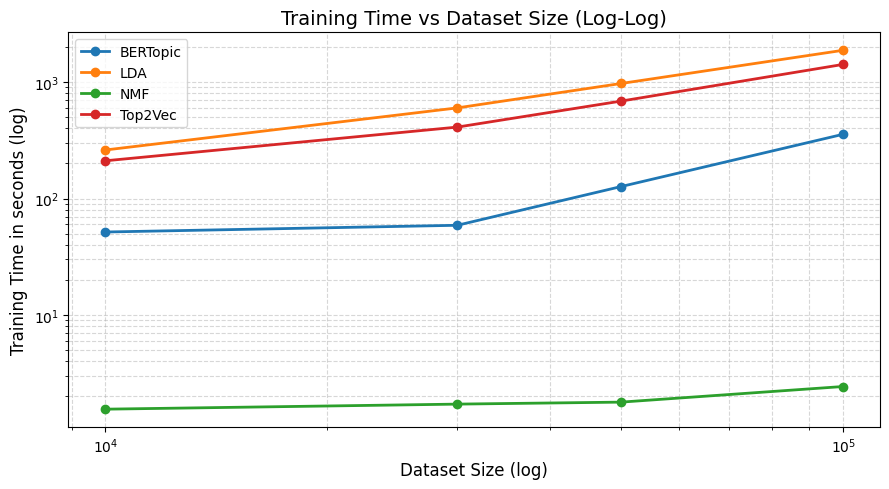

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for algo, grp in results_df.groupby('algorithm'):
    ax.plot(grp['subset_size'], grp['train_time'], marker='o', label=algo, linewidth=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Dataset Size (log)', fontsize=12)
ax.set_ylabel('Training Time in seconds (log)', fontsize=12)
ax.set_title('Training Time vs Dataset Size (Log-Log)', fontsize=14)
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_time_vs_size.png', dpi=150)
plt.show()

Why log-log scale: NMF trains in 1–2 seconds while LDA takes 1873 seconds. On a normal scale, NMF would be invisible at the bottom. Log scale compresses the range so all algorithms are visible and comparable. On a log-log plot, a straight line means perfectly linear scaling — steeper slope means worse scalability.
What your graph reveals:

NMF is nearly flat — barely changes from 10k to 100k (incredible scaling)
LDA and Top2Vec grow steeply — roughly linear in time with data
BERTopic grows but slower than LDA/Top2Vec

#  Plot 2: Peak Memory vs Dataset Size

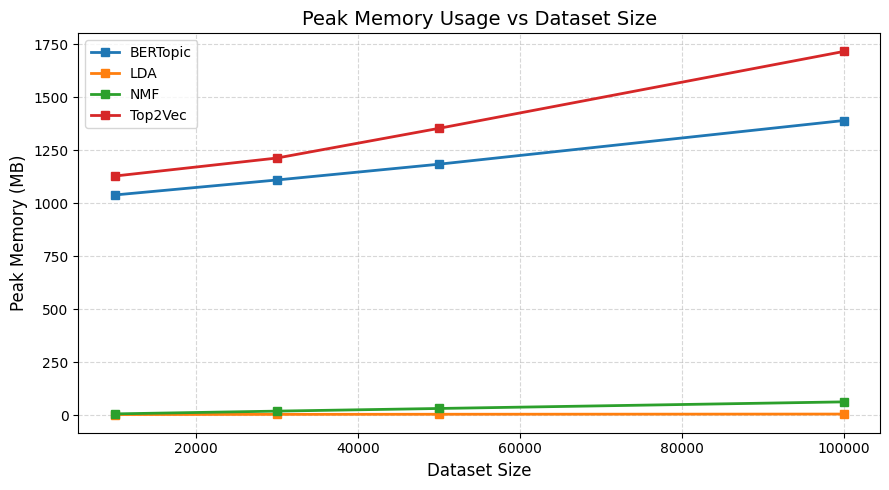

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for algo, grp in results_df.groupby('algorithm'):
    ax.plot(grp['subset_size'], grp['peak_mem_mb'], marker='s', label=algo, linewidth=2)

ax.set_xlabel('Dataset Size', fontsize=12)
ax.set_ylabel('Peak Memory (MB)', fontsize=12)
ax.set_title('Peak Memory Usage vs Dataset Size', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_memory_vs_size.png', dpi=150)
plt.show()

What it shows: Peak RAM usage for each algorithm at each subset size.
What your graph reveals:

BERTopic and Top2Vec start at ~1GB even at 10k — because neural embeddings are dense matrices stored entirely in memory
LDA stays almost flat (3→6 MB) — because sparse bag-of-words takes almost no space
NMF grows linearly (7→63 MB) — the TF-IDF matrix grows with data but stays manageable

Why this matters for production: A system with 8GB RAM cannot run Top2Vec on very large datasets. NMF or LDA would be the only viable options.

#Plot 3: Coherence vs Training Time

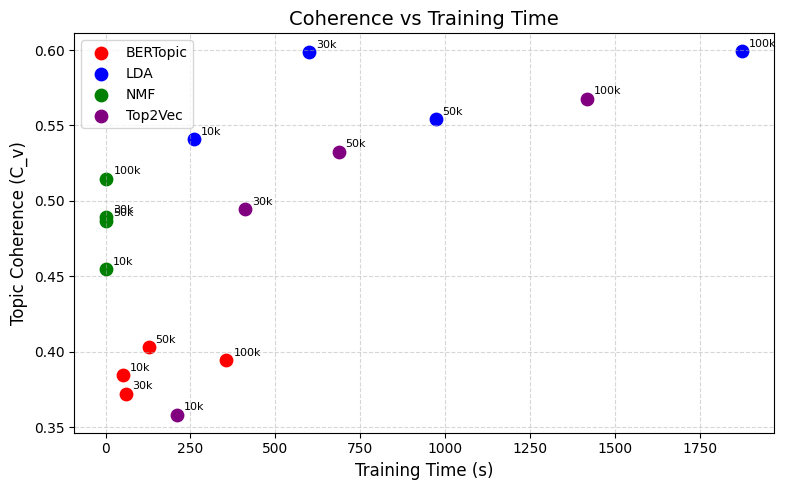

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'LDA': 'blue', 'NMF': 'green', 'BERTopic': 'red', 'Top2Vec': 'purple'}

for algo, grp in results_df.groupby('algorithm'):
    grp_valid = grp.dropna(subset=['coherence'])
    ax.scatter(grp_valid['train_time'], grp_valid['coherence'],
               label=algo, color=colors.get(algo), s=80)
    for _, row in grp_valid.iterrows():
        ax.annotate(f"{int(row['subset_size']//1000)}k",
                    (row['train_time'], row['coherence']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xlabel('Training Time (s)', fontsize=12)
ax.set_ylabel('Topic Coherence (C_v)', fontsize=12)
ax.set_title('Coherence vs Training Time', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_coherence_vs_time.png', dpi=150)
plt.show()

# Plot 4: Trade-off Heatmap (normalized metrics across algorithms @ 100k)

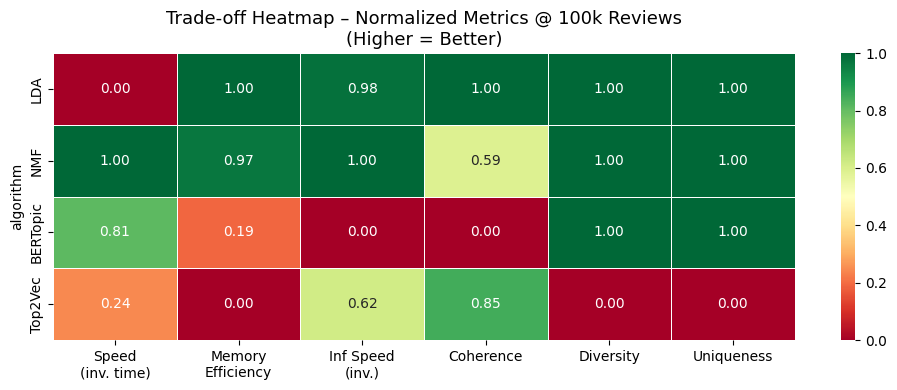

In [ ]:
# Use 100k subset for final comparison
df_100k = results_df[results_df['subset_size'] == 100000].copy()
df_100k = df_100k.set_index('algorithm')

metrics = ['train_time', 'peak_mem_mb', 'inf_time_ms', 'coherence', 'diversity', 'uniqueness']
heatmap_df = df_100k[metrics].copy().astype(float)

# Normalize 0-1 per column
for col in heatmap_df.columns:
    col_min, col_max = heatmap_df[col].min(), heatmap_df[col].max()
    if col_max != col_min:
        heatmap_df[col] = (heatmap_df[col] - col_min) / (col_max - col_min)
    else:
        heatmap_df[col] = 0.5

# Invert cost metrics so higher = better uniformly
for col in ['train_time', 'peak_mem_mb', 'inf_time_ms']:
    heatmap_df[col] = 1 - heatmap_df[col]

heatmap_df.columns = ['Speed\n(inv. time)', 'Memory\nEfficiency', 'Inf Speed\n(inv.)',
                       'Coherence', 'Diversity', 'Uniqueness']

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Trade-off Heatmap – Normalized Metrics @ 100k Reviews\n(Higher = Better)', fontsize=13)
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150)
plt.show()

#  Efficiency Metrics Table

In [ ]:
print("\n{'='*70}")
print("EFFICIENCY METRICS SUMMARY")
print('='*70)
for size in subset_sizes:
    print(f"\n  Subset Size: {size:,} reviews")
    print(f"  {'Algorithm':<12} {'Train(s)':>10} {'Mem(MB)':>10} {'Inf(ms)':>10}")
    print(f"  {'-'*45}")
    sub = results_df[results_df['subset_size'] == size]
    for _, row in sub.iterrows():
        print(f"  {row['algorithm']:<12} {row['train_time']:>10.2f} {row['peak_mem_mb']:>10.2f} {row['inf_time_ms']:>10.4f}")




{'='*70}
EFFICIENCY METRICS SUMMARY

  Subset Size: 10,000 reviews
  Algorithm      Train(s)    Mem(MB)    Inf(ms)
  ---------------------------------------------
  LDA              260.91       3.78     0.2247
  NMF                1.55       7.01     0.0334
  BERTopic          51.58    1038.70     7.9490
  Top2Vec          210.77    1127.93     2.0514

  Subset Size: 30,000 reviews
  Algorithm      Train(s)    Mem(MB)    Inf(ms)
  ---------------------------------------------
  LDA              599.79       4.66     0.2340
  NMF                1.72      20.02     0.0698
  BERTopic          58.92    1109.29     4.0540
  Top2Vec          410.36    1212.67     3.7119

  Subset Size: 50,000 reviews
  Algorithm      Train(s)    Mem(MB)    Inf(ms)
  ---------------------------------------------
  LDA              971.44       5.23     0.3619
  NMF                1.79      32.49     0.0336
  BERTopic         126.63    1183.62     4.8445
  Top2Vec          685.85    1352.54     2.5404

  Sub

In [ ]:
print("\nQUALITY METRICS SUMMARY @ 100k")
print('='*70)
sub = results_df[results_df['subset_size'] == 100000]
print(f"{'Algorithm':<12} {'Coherence':>12} {'Diversity':>12} {'Uniqueness':>12}")
print('-'*50)
for _, row in sub.iterrows():
    print(f"{row['algorithm']:<12} {str(round(row['coherence'],4) if row['coherence'] else 'N/A'):>12} "
          f"{str(round(row['diversity'],4) if row['diversity'] else 'N/A'):>12} "
          f"{str(round(row['uniqueness'],4) if row['uniqueness'] else 'N/A'):>12}")


QUALITY METRICS SUMMARY @ 100k
Algorithm       Coherence    Diversity   Uniqueness
--------------------------------------------------
LDA                 0.599         0.67         0.67
NMF                0.5148         0.67         0.67
BERTopic           0.3947       0.6694       0.6694
Top2Vec            0.5679       0.1445       0.1445


In [ ]:
print("QUALITY METRICS — ALL SUBSET SIZES")
print("="*75)

metrics_to_show = ['coherence', 'diversity', 'uniqueness']

for metric in metrics_to_show:
    print(f"\n  {metric.upper()}")
    print(f"  {'Algorithm':<12}", end="")
    for size in subset_sizes:
        print(f"  {str(size):>10}", end="")
    print()
    print(f"  {'-'*55}")

    for algo in ['LDA', 'NMF', 'BERTopic', 'Top2Vec']:
        print(f"  {algo:<12}", end="")
        for size in subset_sizes:
            val = results_df[
                (results_df['algorithm'] == algo) &
                (results_df['subset_size'] == size)
            ][metric].values[0]
            if val is not None and not pd.isna(val):
                print(f"  {val:>10.4f}", end="")
            else:
                print(f"  {'N/A':>10}", end="")
        print()

QUALITY METRICS — ALL SUBSET SIZES

  COHERENCE
  Algorithm          10000       30000       50000      100000
  -------------------------------------------------------
  LDA               0.5408      0.5987      0.5545      0.5990
  NMF               0.4548      0.4895      0.4869      0.5148
  BERTopic          0.3843      0.3722      0.4030      0.3947
  Top2Vec           0.3583      0.4947      0.5326      0.5679

  DIVERSITY
  Algorithm          10000       30000       50000      100000
  -------------------------------------------------------
  LDA               0.4800      0.5600      0.6500      0.6700
  NMF               0.7100      0.6900      0.6800      0.6700
  BERTopic          0.8154      0.7416      0.7086      0.6694
  Top2Vec           0.5891      0.2586      0.1799      0.1445

  UNIQUENESS
  Algorithm          10000       30000       50000      100000
  -------------------------------------------------------
  LDA               0.4800      0.5600      0.6500      0.

 in COHERENCE : Top2Vec improves significantly with more data (0.36 → 0.57) while BERTopic stays flat regardless of data size.
 2. BERTopic diversity drops as data grows — 0.815 at 10k down to 0.669 at 100k. More data → more topics → more word overlap between nearby topics.
 3. Top2Vec diversity collapses — 0.589 at 10k down to 0.144 at 100k. With 1948 topics at 100k, topics inevitably share vocabulary.